<a href="https://colab.research.google.com/github/klimanyusuf/cold-chain-prediction/blob/master/cold_chain_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime, timedelta

In [27]:
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully")

# In[2]: Generate synthetic cold chain data
def generate_cold_chain_data(duration_days=7, interval_minutes=5, failure_rate=0.02):
    total_records = int(duration_days * 24 * 60 / interval_minutes)
    start_time = datetime.now() - timedelta(days=duration_days)
    records = []
    base_drift = 0.0
    device_ids = [f"DEV-{i:03d}" for i in range(1, 6)]

    for i in range(total_records):
        timestamp = start_time + timedelta(minutes=i * interval_minutes)
        hour = timestamp.hour
        device_id = device_ids[i % len(device_ids)]

        daily_variation = 1.5 * abs((hour - 14) / 12)
        noise = np.random.normal(0, 0.3)

        if i > 800:
            base_drift = min(1.5, base_drift + 0.001)

        temp = 5.0 + base_drift + daily_variation + noise

        has_failure = 0
        if np.random.random() < failure_rate:
            has_failure = 1
            temp = temp + np.random.uniform(0.5, 3.0)
            base_drift = base_drift + np.random.uniform(0, 0.02)

        temp = max(-2, min(15, temp))
        door_open = 1 if (8 <= hour <= 18 and np.random.random() < 0.08) else (1 if np.random.random() < 0.02 else 0)

        battery_drain = 0.008
        if door_open:
            battery_drain += 0.015
        if temp > 8:
            battery_drain += 0.01
        battery = max(0, min(100, 100 - i * battery_drain * 60 / interval_minutes + np.random.normal(0, 1)))

        humidity = max(30, min(90, 60 - (temp - 5) * 2 + np.random.normal(0, 5)))

        records.append({
            "timestamp": timestamp.isoformat(),
            "device_id": device_id,
            "temperature_celsius": round(temp, 1),
            "humidity_percent": round(humidity, 0),
            "battery_percent": round(battery, 0),
            "door_open": door_open,
            "has_failure": has_failure
        })

    return pd.DataFrame(records)

✅ All libraries imported successfully


✅ Dataset generated: 2016 records
   Failure rate: 1.8%
                    timestamp device_id  temperature_celsius  \
0  2026-04-29T12:42:20.059240   DEV-001                  5.4   
1  2026-04-29T12:47:20.059240   DEV-002                  5.6   
2  2026-04-29T12:52:20.059240   DEV-003                  5.1   
3  2026-04-29T12:57:20.059240   DEV-004                  5.3   
4  2026-04-29T13:02:20.059240   DEV-005                  5.9   

   humidity_percent  battery_percent  door_open  has_failure  
0              61.0            100.0          0            0  
1              56.0             99.0          1            0  
2              55.0             99.0          0            0  
3              62.0             99.0          0            0  
4              55.0            100.0          0            0  


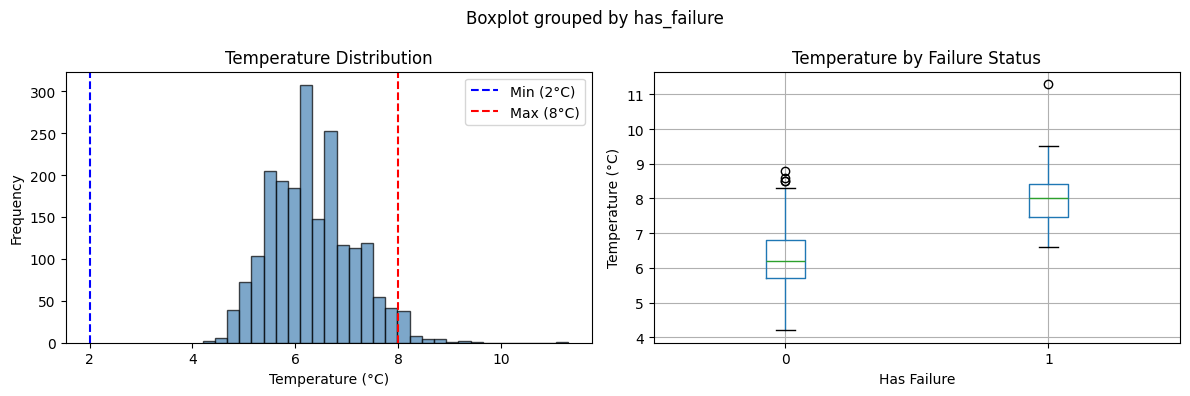

In [28]:
df = generate_cold_chain_data()
print(f"✅ Dataset generated: {len(df)} records")
print(f"   Failure rate: {df['has_failure'].mean()*100:.1f}%")
print(df.head())

# In[3]: EDA - Temperature distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['temperature_celsius'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=2, color='blue', linestyle='--', label='Min (2°C)')
axes[0].axvline(x=8, color='red', linestyle='--', label='Max (8°C)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Temperature Distribution')
axes[0].legend()

df.boxplot(column='temperature_celsius', by='has_failure', ax=axes[1])
axes[1].set_xlabel('Has Failure')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Temperature by Failure Status')

plt.tight_layout()
plt.show()

In [29]:
df.head(5)

,timestamp,device_id,temperature_celsius,humidity_percent,battery_percent,door_open,has_failure
0,2026-04-29T12:42:20.059240,DEV-001,5.4,61.0,100.0,0,0
1,2026-04-29T12:47:20.059240,DEV-002,5.6,56.0,99.0,1,0
2,2026-04-29T12:52:20.059240,DEV-003,5.1,55.0,99.0,0,0
3,2026-04-29T12:57:20.059240,DEV-004,5.3,62.0,99.0,0,0
4,2026-04-29T13:02:20.059240,DEV-005,5.9,55.0,100.0,0,0


In [30]:
#In[4]: Feature engineering
def preprocess_data(df):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['temp_rate_change'] = df['temperature_celsius'].diff().fillna(0)
    df['temp_rolling_mean'] = df['temperature_celsius'].rolling(window=12, min_periods=1).mean()
    df['temp_rolling_std'] = df['temperature_celsius'].rolling(window=12, min_periods=1).std().fillna(0)
    df['door_open_count'] = df['door_open'].rolling(window=12, min_periods=1).sum()

    df['hours_since_failure'] = 0
    last_failure_idx = -1
    for i, is_failure in enumerate(df['has_failure']):
        if is_failure == 1:
            last_failure_idx = i
            df.loc[i, 'hours_since_failure'] = 0
        elif last_failure_idx != -1:
            hours_passed = (i - last_failure_idx) * 5 / 60
            df.loc[i, 'hours_since_failure'] = hours_passed

    feature_cols = ['temperature_celsius', 'humidity_percent', 'battery_percent',
                    'temp_rate_change', 'temp_rolling_mean', 'temp_rolling_std',
                    'door_open_count', 'hour', 'day_of_week', 'hours_since_failure']

    return df, feature_cols

df_processed, feature_cols = preprocess_data(df)
X = df_processed[feature_cols].values
y = df_processed['has_failure'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_cols}")

Feature matrix shape: (2016, 10)
Features: ['temperature_celsius', 'humidity_percent', 'battery_percent', 'temp_rate_change', 'temp_rolling_mean', 'temp_rolling_std', 'door_open_count', 'hour', 'day_of_week', 'hours_since_failure']


In [36]:
df_processed.head(5)

,timestamp,device_id,temperature_celsius,humidity_percent,battery_percent,door_open,has_failure,hour,day_of_week,temp_rate_change,temp_rolling_mean,temp_rolling_std,door_open_count,hours_since_failure
0,2026-04-29 12:42:20.059240,DEV-001,5.4,61.0,100.0,0,0,12,2,0.0,5.400000,0.000000,0.0,0.0
1,2026-04-29 12:47:20.059240,DEV-002,5.6,56.0,99.0,1,0,12,2,0.2,5.500000,0.141421,1.0,0.0
2,2026-04-29 12:52:20.059240,DEV-003,5.1,55.0,99.0,0,0,12,2,-0.5,5.366667,0.251661,1.0,0.0
3,2026-04-29 12:57:20.059240,DEV-004,5.3,62.0,99.0,0,0,12,2,0.2,5.350000,0.208167,1.0,0.0
4,2026-04-29 13:02:20.059240,DEV-005,5.9,55.0,100.0,0,0,13,2,0.6,5.460000,0.304959,1.0,0.0


In [31]:
# In[5]: Train/validation/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {len(X_train)} samples ({y_train.sum()} failures)")
print(f"Test: {len(X_test)} samples ({y_test.sum()} failures)")

# In[6]: Train XGBoost
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = {0: class_weights[0], 1: class_weights[1]}

xgb_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42,
    eval_metric='logloss', scale_pos_weight=weight_dict[1]/weight_dict[0]
)

xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)], verbose=False)

y_pred = xgb_model.predict(X_test_scaled)
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

Training: 1411 samples (25 failures)
Test: 303 samples (6 failures)

XGBOOST RESULTS
Accuracy:  1.0000 (100.0%)
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
AUC:       1.0000


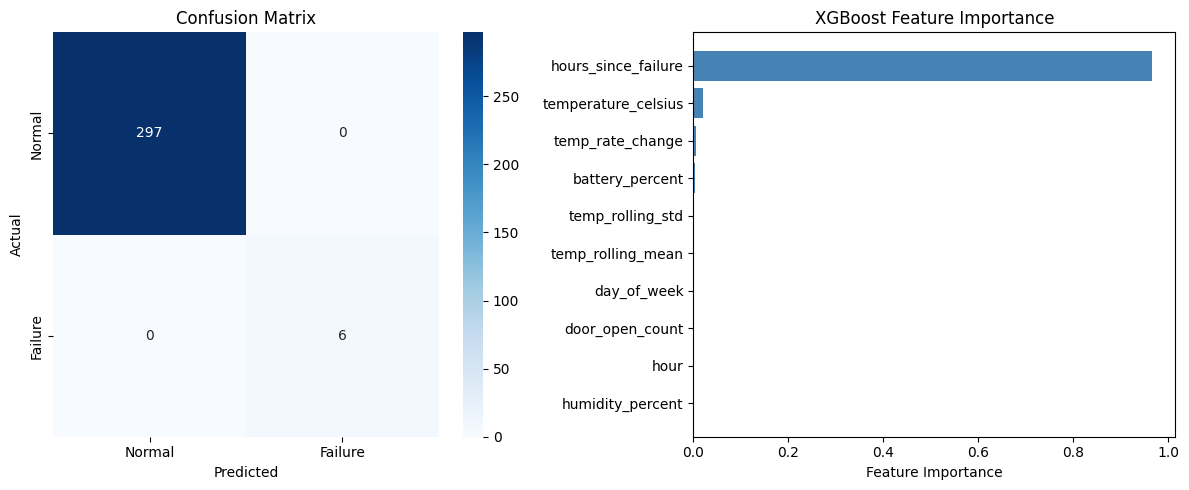

In [32]:
# In[7]: Confusion matrix and feature importance
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

importance = xgb_model.feature_importances_
sorted_idx = np.argsort(importance)[::-1]
sorted_features = [feature_cols[i] for i in sorted_idx]
sorted_importance = importance[sorted_idx]

axes[1].barh(range(len(sorted_features)), sorted_importance, color='steelblue')
axes[1].set_yticks(range(len(sorted_features)))
axes[1].set_yticklabels(sorted_features)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('XGBoost Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [33]:
# In[8]: Prepare LSTM sequences
def create_sequences(data, seq_length=12, forecast_horizon=12):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length - forecast_horizon):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(data[i+seq_length+forecast_horizon])
    return np.array(X_seq), np.array(y_seq)

temp_data = df['temperature_celsius'].values.reshape(-1, 1)
temp_mean = temp_data.mean()
temp_std = temp_data.std()
temp_data_norm = (temp_data - temp_mean) / temp_std

SEQ_LENGTH = 12
FORECAST_HORIZON = 12

X_seq, y_seq = create_sequences(temp_data_norm.flatten(), SEQ_LENGTH, FORECAST_HORIZON)
print(f"Sequences created: {X_seq.shape}")

train_size = int(len(X_seq) * 0.7)
val_size = int(len(X_seq) * 0.15)

X_train_lstm = X_seq[:train_size]
y_train_lstm = y_seq[:train_size]
X_val_lstm = X_seq[train_size:train_size+val_size]
y_val_lstm = y_seq[train_size:train_size+val_size]
X_test_lstm = X_seq[train_size+val_size:]
y_test_lstm = y_seq[train_size+val_size:]

X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_val_lstm = X_val_lstm.reshape(X_val_lstm.shape[0], X_val_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

Sequences created: (1992, 12)


In [23]:
#In[9]: Train LSTM
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100, batch_size=32, callbacks=[early_stop], verbose=1
)

# In[10]: LSTM evaluation
y_pred_lstm_norm = lstm_model.predict(X_test_lstm, verbose=0)
y_test_actual = y_test_lstm * temp_std + temp_mean
y_pred_actual = y_pred_lstm_norm.flatten() * temp_std + temp_mean

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("\n" + "=" * 50)
print("LSTM RESULTS")
print("=" * 50)
print(f"MAE:  {mae:.4f}°C")
print(f"RMSE: {rmse:.4f}°C")
print(f"✅ Target Achieved: MAE ({mae:.3f}°C) < 1.0°C" if mae < 1.0 else f"⚠️ Target not achieved")

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.4207 - mae: 0.4802 - val_loss: 0.3719 - val_mae: 0.4644
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3574 - mae: 0.4368 - val_loss: 0.4137 - val_mae: 0.4926
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3574 - mae: 0.4380 - val_loss: 0.3805 - val_mae: 0.4706
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3545 - mae: 0.4342 - val_loss: 0.3747 - val_mae: 0.4678
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3608 - mae: 0.4391 - val_loss: 0.3730 - val_mae: 0.4673
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3566 - mae: 0.4350 - val_loss: 0.3673 - val_mae: 0.4633
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3502 - mae: 0.4287 - val_loss: 0.3682 - val_mae: 0.4635
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3533 - mae: 0.4300 - val_loss: 0.3552 - val_mae: 0.4554
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - lo

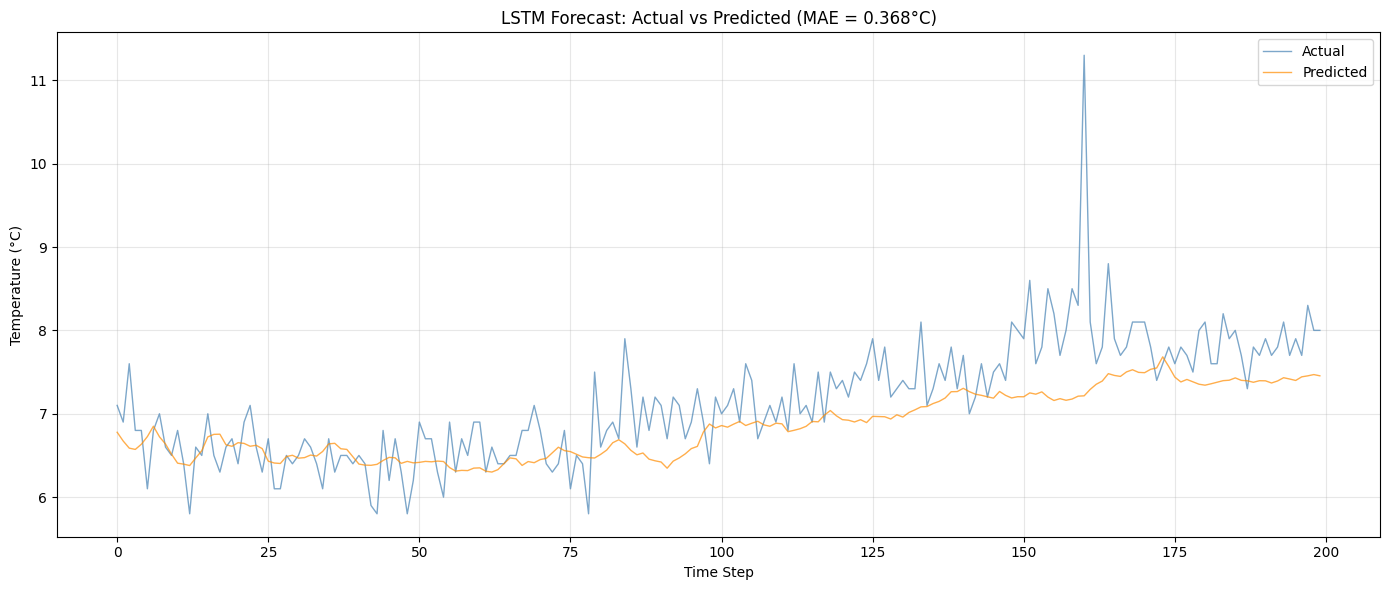

In [24]:
# In[11]: Plot LSTM predictions
plt.figure(figsize=(14, 6))
n_samples = min(200, len(y_test_actual))
plt.plot(y_test_actual[:n_samples], label='Actual', alpha=0.7, linewidth=1, color='steelblue')
plt.plot(y_pred_actual[:n_samples], label='Predicted', alpha=0.7, linewidth=1, color='darkorange')
plt.xlabel('Time Step')
plt.ylabel('Temperature (°C)')
plt.title(f'LSTM Forecast: Actual vs Predicted (MAE = {mae:.3f}°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# In[12]: Final summary
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"XGBoost Accuracy: {accuracy*100:.1f}%")
print(f"XGBoost F1 Score: {f1:.3f}")
print(f"XGBoost AUC: {auc:.3f}")
print(f"\nLSTM MAE: {mae:.3f}°C")
print(f"LSTM RMSE: {rmse:.3f}°C")
print("\n✅ XGBoost excels at FAILURE DETECTION")
print("✅ LSTM excels at TEMPERATURE FORECASTING")
print("\n" + "=" * 60)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 60)


MODEL COMPARISON SUMMARY
XGBoost Accuracy: 100.0%
XGBoost F1 Score: 1.000
XGBoost AUC: 1.000

LSTM MAE: 0.368°C
LSTM RMSE: 0.523°C

✅ XGBoost excels at FAILURE DETECTION
✅ LSTM excels at TEMPERATURE FORECASTING

NOTEBOOK EXECUTION COMPLETE
